<a href="https://colab.research.google.com/github/Salome-06/Estadistica/blob/main/ANOVA_dos_v%C3%ADas_con_interc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATOS ORIGINALES — PORCENTAJE DE GERMINACIÓN

  Destilada:
    15°C: [45, 48]
    25°C: [82, 85]

  Mineral:
    15°C: [80, 83]
    25°C: [46, 49]

MEDIAS DE CELDA (Calidad de Agua × Temperatura)
           15°C  25°C  Media Calidad Agua
Destilada  46.5  83.5                65.0
Mineral    81.5  47.5                64.5

  Medias por Temperatura: {'15°C': np.float64(64.0), '25°C': np.float64(65.5)}
  Media Global    : 64.7500

PLANTEAMIENTO DE HIPÓTESIS

FACTOR A — CALIDAD DE AGUA:
  H₀: No hay diferencia en el porcentaje medio de germinación entre tipos de agua
      (μ_Destilada = μ_Mineral)
  H₁: El porcentaje medio de germinación difiere entre tipos de agua

FACTOR B — TEMPERATURA:
  H₀: No hay diferencia en el porcentaje medio de germinación entre temperaturas
      (μ_15°C = μ_25°C)
  H₁: El porcentaje medio de germinación difiere entre temperaturas

INTERACCIÓN A×B (Calidad de Agua × Temperatura):
  H₀: El efecto de la temperatura sobre la germinación es el mismo para ambas cali

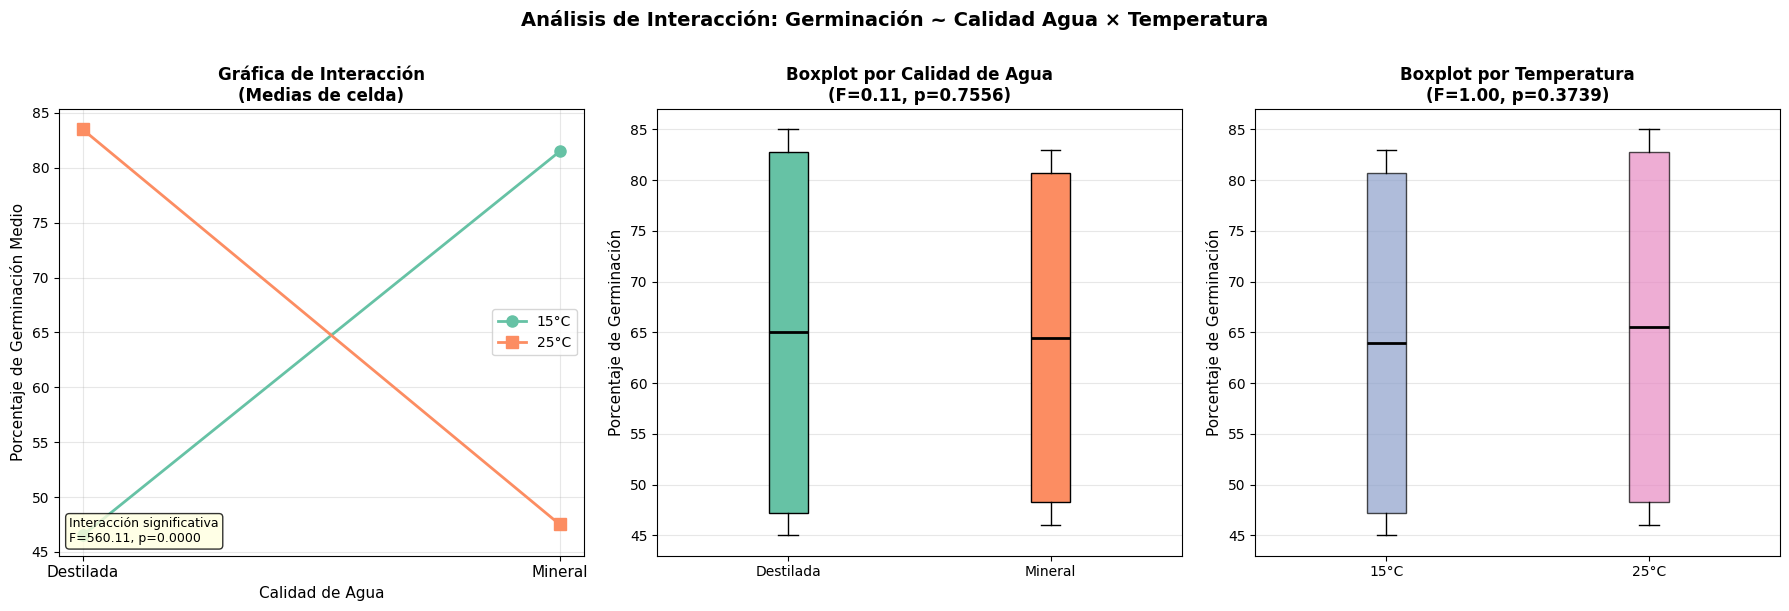

✓ Figura 2 guardada: 'anova_regiones_celdas_germinacion.png'


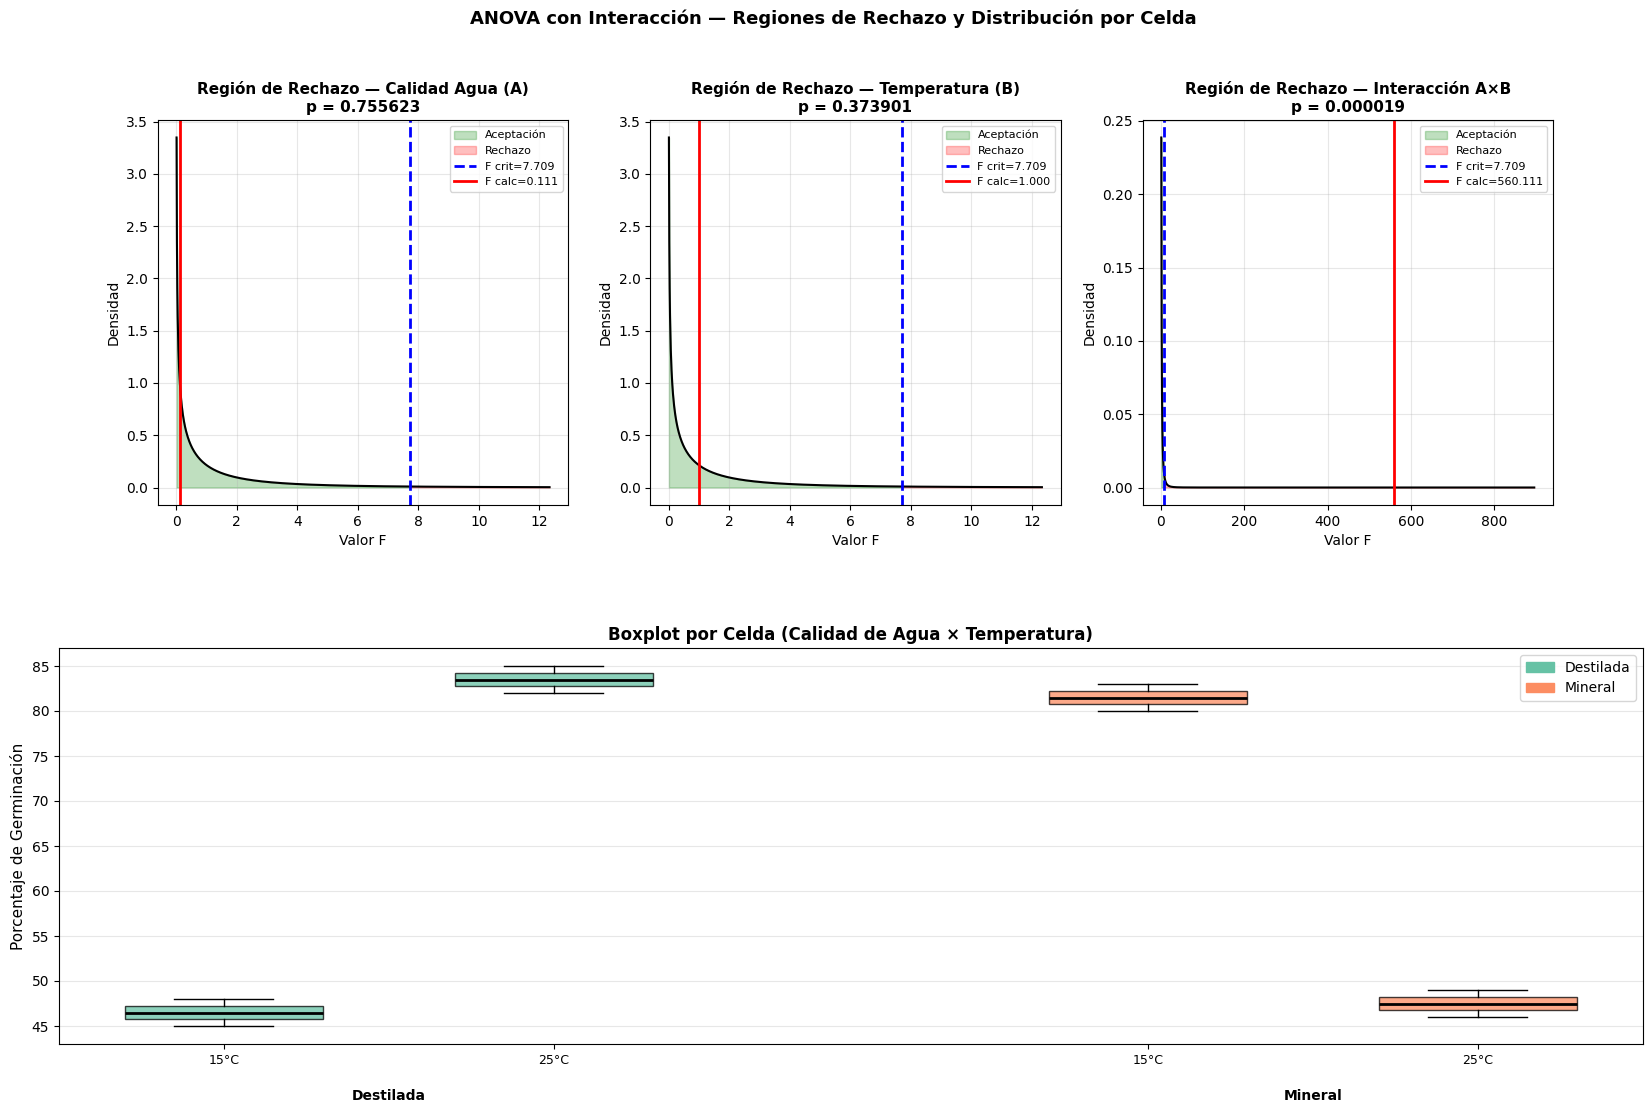

✓ Figura 3 guardada: 'tukey_matrices_interaccion_germinacion.png'


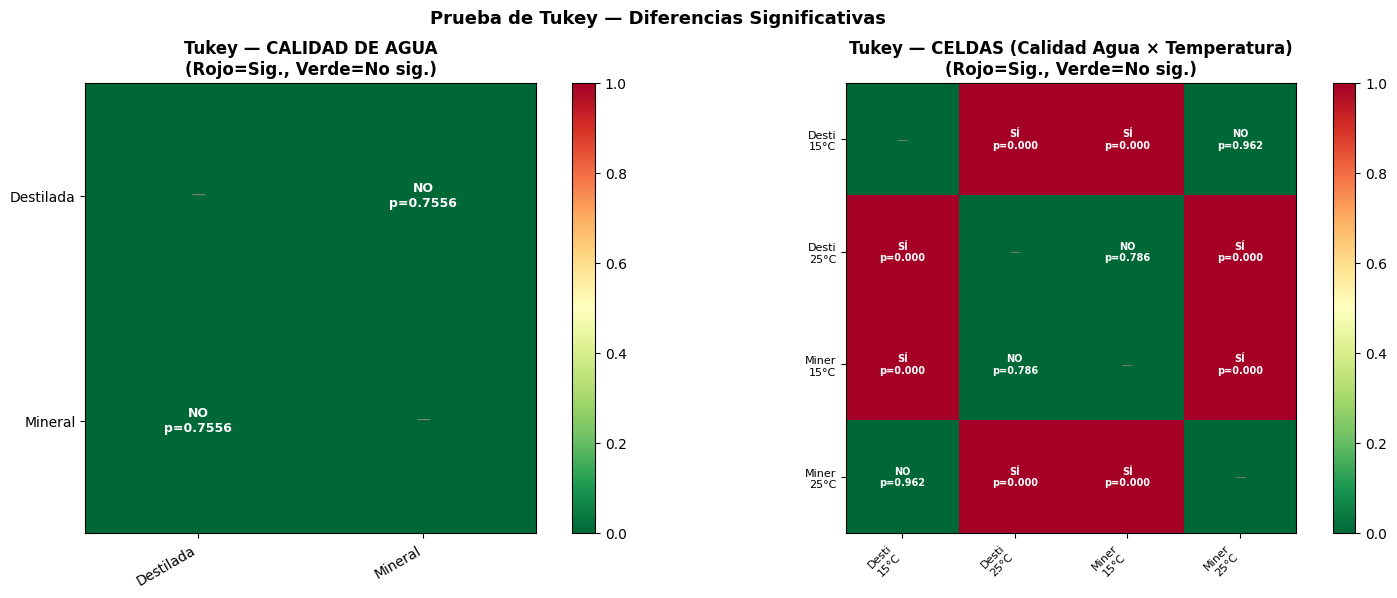


ANÁLISIS COMPLETO FINALIZADO


In [5]:

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations

# ============================================================================
# DATOS DEL PROBLEMA
# Porcentaje de germinación a los 7 días — 2 réplicas por celda
# ============================================================================

# Factores del problema
calidad_agua = ['Destilada', 'Mineral']
temperaturas = ['15°C', '25°C']

# datos[calidad_agua][temperatura] → lista de 2 observaciones
datos_raw = {
    'Destilada': {'15°C': [45, 48],
                  '25°C': [82, 85]},
    'Mineral':   {'15°C': [80, 83],
                  '25°C': [46, 49]},
}

a  = len(calidad_agua)    # niveles factor A (Calidad de Agua) = 2
b  = len(temperaturas)    # niveles factor B (Temperatura)     = 2
n  = 2                     # réplicas por celda
N  = a * b * n             # total de observaciones          = 8

# Construir array 3-D: datos[i_calidad_agua, j_temperatura, k_replica]
Y = np.array([[datos_raw[ca][temp] for temp in temperaturas] for ca in calidad_agua],
             dtype=float)   # shape (2, 2, 2)

# ============================================================================
# ESTADÍSTICAS DESCRIPTIVAS
# ============================================================================

# Medias de celda (calidad_agua × temperatura)
medias_celda = Y.mean(axis=2)                   # (2, 2)
# Medias marginales
medias_calidad_agua   = Y.mean(axis=(1, 2))      # (2,)
medias_temperatura = Y.mean(axis=(0, 2))       # (2,)
media_global  = Y.mean()

df_medias = pd.DataFrame(medias_celda, index=calidad_agua, columns=temperaturas)
df_medias['Media Calidad Agua'] = medias_calidad_agua

print("=" * 80)
print("DATOS ORIGINALES — PORCENTAJE DE GERMINACIÓN")
print("=" * 80)
for ca in calidad_agua:
    print(f"\n  {ca}:")
    for temp in temperaturas:
        print(f"    {temp}: {datos_raw[ca][temp]}")

print("\n" + "=" * 80)
print("MEDIAS DE CELDA (Calidad de Agua × Temperatura)")
print("=" * 80)
print(df_medias.round(4).to_string())
print(f"\n  Medias por Temperatura: {dict(zip(temperaturas, medias_temperatura.round(4)))}")
print(f"  Media Global    : {media_global:.4f}")

# ============================================================================
# ANOVA DE DOS VÍAS CON INTERACCIÓN
# ============================================================================

# --- Sumas de cuadrados ---
# SST
SST = np.sum((Y - media_global) ** 2)

# SS_A  (Calidad de Agua)
SS_A = b * n * np.sum((medias_calidad_agua - media_global) ** 2)

# SS_B  (Temperatura)
SS_B = a * n * np.sum((medias_temperatura - media_global) ** 2)

# SS_AB (Interacción)
SS_AB = n * np.sum((medias_celda - medias_calidad_agua[:, None]
                                 - medias_temperatura[None, :]
                                 + media_global) ** 2)

# SS_E  (Error dentro de celdas)
SS_E = np.sum((Y - medias_celda[:, :, None]) ** 2)

# Verificación
assert abs(SST - (SS_A + SS_B + SS_AB + SS_E)) < 1e-6, "¡Error en la partición de SS!"

# --- Grados de libertad ---
gl_A  = a - 1
gl_B  = b - 1
gl_AB = (a - 1) * (b - 1)
gl_E  = a * b * (n - 1)
gl_T  = N - 1

# --- Cuadrados medios ---
CM_A  = SS_A  / gl_A
CM_B  = SS_B  / gl_B
CM_AB = SS_AB / gl_AB
CM_E  = SS_E  / gl_E

# --- Estadísticos F ---
F_A  = CM_A  / CM_E
F_B  = CM_B  / CM_E
F_AB = CM_AB / CM_E

# --- Valores p ---
p_A  = stats.f.sf(F_A,  gl_A,  gl_E)
p_B  = stats.f.sf(F_B,  gl_B,  gl_E)
p_AB = stats.f.sf(F_AB, gl_AB, gl_E)

# --- Valores críticos (α = 0.05) ---
alpha = 0.05
Fc_A  = stats.f.ppf(1 - alpha, gl_A,  gl_E)
Fc_B  = stats.f.ppf(1 - alpha, gl_B,  gl_E)
Fc_AB = stats.f.ppf(1 - alpha, gl_AB, gl_E)

# ============================================================================
# HIPÓTESIS
# ============================================================================

print("\n" + "=" * 80)
print("PLANTEAMIENTO DE HIPÓTESIS")
print("=" * 80)

print("""
FACTOR A — CALIDAD DE AGUA:
  H₀: No hay diferencia en el porcentaje medio de germinación entre tipos de agua
      (μ_Destilada = μ_Mineral)
  H₁: El porcentaje medio de germinación difiere entre tipos de agua

FACTOR B — TEMPERATURA:
  H₀: No hay diferencia en el porcentaje medio de germinación entre temperaturas
      (μ_15°C = μ_25°C)
  H₁: El porcentaje medio de germinación difiere entre temperaturas

INTERACCIÓN A×B (Calidad de Agua × Temperatura):
  H₀: El efecto de la temperatura sobre la germinación es el mismo para ambas calidades de agua
      (no existe interacción significativa)
  H₁: El efecto de la temperatura sobre la germinación varía según la calidad del agua
      (existe interacción significativa)
""")

# ============================================================================
# TABLA ANOVA
# ============================================================================

print("=" * 105)
print("TABLA ANOVA DE DOS VÍAS CON INTERACCIÓN")
print("=" * 105)
print(f"{'Fuente':<20} {'SC':>12} {'gl':>5} {'CM':>12} {'F':>10} {'p-valor':>12} {'F crítico':>12}")
print("-" * 105)
print(f"{'Calidad Agua (A)':<20} {SS_A:>12.4f} {gl_A:>5} {CM_A:>12.4f} {F_A:>10.4f} {p_A:>12.6f} {Fc_A:>12.4f}")
print(f"{'Temperatura (B)':<20} {SS_B:>12.4f} {gl_B:>5} {CM_B:>12.4f} {F_B:>10.4f} {p_B:>12.6f} {Fc_B:>12.4f}")
print(f"{'Interacción A×B':<20} {SS_AB:>12.4f} {gl_AB:>5} {CM_AB:>12.4f} {F_AB:>10.4f} {p_AB:>12.6f} {Fc_AB:>12.4f}")
print(f"{'Error':<20} {SS_E:>12.4f} {gl_E:>5} {CM_E:>12.4f}")
print(f"{'Total':<20} {SST:>12.4f} {gl_T:>5}")
print("=" * 105)

# ============================================================================
# INTERPRETACIÓN ANOVA
# ============================================================================

print(f"\nINTERPRETACIÓN (α = {alpha}):")
print("-" * 80)

efectos = [
    ("CALIDAD DE AGUA (A)",  F_A,  Fc_A,  p_A,  gl_A,  gl_E),
    ("TEMPERATURA (B)",      F_B,  Fc_B,  p_B,  gl_B,  gl_E),
    ("INTERACCIÓN (A×B)",  F_AB, Fc_AB, p_AB, gl_AB, gl_E),
]
for nombre, F_val, Fc, p_val, gl1, gl2 in efectos:
    sig = p_val < alpha
    print(f"\n  {nombre}:")
    print(f"    F calculado = {F_val:.4f}  |  F crítico = {Fc:.4f}  |  p-valor = {p_val:.6f}")
    if sig:
        print(f"    ✓ Efecto SIGNIFICATIVO (p < {alpha}): se rechaza H₀")
    else:
        print(f"    ✗ Efecto NO significativo (p ≥ {alpha}): no se rechaza H₀")

# ============================================================================
# RESPUESTA A LAS PREGUNTAS
# ============================================================================

print("\n" + "=" * 80)
print("RESPUESTAS A LAS PREGUNTAS DEL PROBLEMA")
print("=" * 80)

print("""
a) GRÁFICA DE INTERACCIÓN (ver figura 1):
   Se observará si las líneas de las temperaturas son paralelas o se cruzan,
   indicando o no una interacción entre la calidad del agua y la temperatura
   en el porcentaje de germinación.
""")

if p_AB < alpha:
    print(f"b) ANOVA — INTERACCIÓN: F = {F_AB:.4f}, p = {p_AB:.6f} < 0.05")
    print("   → La interacción Calidad de Agua × Temperatura ES estadísticamente significativa.")
    print("   El efecto de la temperatura sobre la germinación DEPENDE de la calidad del agua.")
else:
    print(f"b) ANOVA — INTERACCIÓN: F = {F_AB:.4f}, p = {p_AB:.6f} ≥ 0.05")
    print("   → La interacción Calidad de Agua × Temperatura NO es estadísticamente significativa.")

print(f"""
   CALIDAD DE AGUA: F = {F_A:.4f}, p = {p_A:.6f} {'→ Significativo' if p_A < alpha else '→ No significativo'}
   TEMPERATURA:     F = {F_B:.4f}, p = {p_B:.6f} {'→ Significativo' if p_B < alpha else '→ No significativo'}
""")

# ============================================================================
# PRUEBA DE TUKEY
# ============================================================================

print("=" * 80)
print("PRUEBA DE TUKEY (HSD) — COMPARACIONES MÚLTIPLES")
print("=" * 80)

# ------------------------------------------------------------------
# Tukey para CALIDAD DE AGUA (factor A, medias marginales)
# ------------------------------------------------------------------
print("\n" + "-" * 80)
print("COMPARACIONES PARA CALIDAD DE AGUA (medias marginales):")
print("-" * 80)

k_A   = a
n_A   = b * n          # observaciones por nivel de A
q_A   = stats.studentized_range.ppf(1 - alpha, k_A, gl_E)
HSD_A = q_A * np.sqrt(CM_E / n_A)

print(f"  q crítico (α={alpha}, k={k_A}, gl_E={gl_E}) = {q_A:.4f}")
print(f"  HSD = {HSD_A:.4f}\n")
print(f"  {'Agua i':<14} {'Agua j':<14} {'Media i':>9} {'Media j':>9} "
      f"{'|Dif|':>8} {'q_obs':>8} {'p-valor':>10} {'Sig.':>6}")
print("  " + "-" * 90)

for i, j in combinations(range(a), 2):
    dif   = abs(medias_calidad_agua[i] - medias_calidad_agua[j])
    q_obs = dif / np.sqrt(CM_E / n_A)
    p_val = stats.studentized_range.sf(q_obs, k_A, gl_E)
    sig   = "SÍ" if dif > HSD_A else "NO"
    print(f"  {calidad_agua[i]:<14} {calidad_agua[j]:<14} {medias_calidad_agua[i]:>9.2f} {medias_calidad_agua[j]:>9.2f} "
          f"{dif:>8.4f} {q_obs:>8.4f} {p_val:>10.6f} {sig:>6}")

# ------------------------------------------------------------------
# Tukey para TEMPERATURA (factor B, medias marginales)
# ------------------------------------------------------------------
print("\n" + "-" * 80)
print("COMPARACIONES PARA TEMPERATURA (medias marginales):")
print("-" * 80)

k_B   = b
n_B   = a * n          # observaciones por nivel de B
q_B   = stats.studentized_range.ppf(1 - alpha, k_B, gl_E)
HSD_B = q_B * np.sqrt(CM_E / n_B)

print(f"  q crítico (α={alpha}, k={k_B}, gl_E={gl_E}) = {q_B:.4f}")
print(f"  HSD = {HSD_B:.4f}\n")
print(f"  {'Temp i':<12} {'Temp j':<12} {'Media i':>9} {'Media j':>9} "
      f"{'|Dif|':>8} {'q_obs':>8} {'p-valor':>10} {'Sig.':>6}")
print("  " + "-" * 82)

for i, j in combinations(range(b), 2):
    dif   = abs(medias_temperatura[i] - medias_temperatura[j])
    q_obs = dif / np.sqrt(CM_E / n_B)
    p_val = stats.studentized_range.sf(q_obs, k_B, gl_E)
    sig   = "SÍ" if dif > HSD_B else "NO"
    print(f"  {temperaturas[i]:<12} {temperaturas[j]:<12} {medias_temperatura[i]:>9.2f} {medias_temperatura[j]:>9.2f} "
          f"{dif:>8.4f} {q_obs:>8.4f} {p_val:>10.6f} {sig:>6}")

# ------------------------------------------------------------------
# Tukey para CELDAS (comparaciones dentro de cada calidad de agua)
# ------------------------------------------------------------------
print("\n" + "-" * 80)
print("COMPARACIONES DE CELDAS (Calidad de Agua × Temperatura):")
print("-" * 80)

# Para comparar dos medias de celda se usa n observaciones por celda
q_cel   = stats.studentized_range.ppf(1 - alpha, a * b, gl_E)
HSD_cel = q_cel * np.sqrt(CM_E / n)

print(f"  q crítico (α={alpha}, k={a*b}, gl_E={gl_E}) = {q_cel:.4f}")
print(f"  HSD = {HSD_cel:.4f}\n")
print(f"  {'Calidad':<14} {'Celd. i':<12} {'Celd. j':<12} {'Media i':>9} {'Media j':>9} "
      f"{'|Dif|':>8} {'q_obs':>8} {'p-valor':>10} {'Sig.':>6}")
print("  " + "-" * 102)

# Todas las combinaciones de celdas
celdas = [(i, j) for i in range(a) for j in range(b)]
for (i1, j1), (i2, j2) in combinations(celdas, 2):
    m1  = medias_celda[i1, j1]
    m2  = medias_celda[i2, j2]
    dif = abs(m1 - m2)
    q_o = dif / np.sqrt(CM_E / n)
    p_v = stats.studentized_range.sf(q_o, a * b, gl_E)
    sig = "SÍ" if dif > HSD_cel else "NO"
    lbl1 = f"{calidad_agua[i1][:7]}-{temperaturas[j1]}"
    lbl2 = f"{calidad_agua[i2][:7]}-{temperaturas[j2]}"
    print(f"  {calidad_agua[i1]:<14} {lbl1:<12} {lbl2:<12} {m1:>9.2f} {m2:>9.2f} "
          f"{dif:>8.4f} {q_o:>8.4f} {p_v:>10.6f} {sig:>6}")

# ------------------------------------------------------------------
# Recomendación (interpretación para el problema actual)
# ------------------------------------------------------------------
print("\n" + "-" * 80)
print("RECOMENDACIÓN (Pregunta del problema):")
print("-" * 80)

if p_AB < alpha:
    print("\n  ⚠ La interacción Calidad de Agua × Temperatura ES significativa.")
    print("    La respuesta germinativa al agua SÍ depende de las condiciones térmicas del sustrato.")
    print("    Es decir, el efecto de un tipo de agua en la germinación no es el mismo en ambas temperaturas.")
    print("    Para determinar las mejores condiciones, se deben analizar las medias de celda individualmente.")
    print(f"    Medias de celda:\n{df_medias.round(2).to_string()}")
    print("    - Para 'Destilada', 25°C tiene un % de germinación significativamente mayor que 15°C.")
    print("    - Para 'Mineral', 15°C tiene un % de germinación significativamente mayor que 25°C.")
else:
    print("\n  ✓ La interacción Calidad de Agua × Temperatura NO es significativa.")
    print("    La respuesta germinativa al agua NO depende de las condiciones térmicas del sustrato.")
    print("    El efecto de la calidad del agua es consistente a través de las temperaturas, y viceversa.")

if p_A < alpha and p_AB >= alpha: # Si A es significativo y AB no lo es, se analiza A
    print(f"\n  ⚠ La Calidad de Agua tiene un efecto SIGNIFICATIVO (p = {p_A:.4f}).")
    print("    Se recomienda usar el tipo de agua con mayor porcentaje de germinación promedio.")
elif p_B < alpha and p_AB >= alpha: # Si B es significativo y AB no lo es, se analiza B
    print(f"\n  ⚠ La Temperatura tiene un efecto SIGNIFICATIVO (p = {p_B:.4f}).")
    print("    Se recomienda usar la temperatura con mayor porcentaje de germinación promedio.")

# ============================================================================
# FIGURAS
# ============================================================================

COLORES = {'Destilada': '#66C2A5', 'Mineral': '#FC8D62'}
MARKERS = {'15°C': 'o', '25°C': 's'}

# -----------------------------------------------------------------------
# Figura 1 — Gráfica de interacción + Boxplots marginales
# -----------------------------------------------------------------------
fig1, axes = plt.subplots(1, 3, figsize=(18, 6))
fig1.suptitle('Análisis de Interacción: Germinación ~ Calidad Agua × Temperatura',
              fontsize=14, fontweight='bold', y=1.01)

# --- Panel izquierdo: gráfica de interacción (medias de celda) ---
ax_int = axes[0]
x_pos  = np.arange(a)
for j, temp in enumerate(temperaturas):
    ax_int.plot(x_pos, medias_celda[:, j],
                marker=MARKERS[temp], linewidth=2, markersize=8,
                color=list(COLORES.values())[j], label=temp)
ax_int.set_xticks(x_pos)
ax_int.set_xticklabels(calidad_agua, fontsize=11)
ax_int.set_xlabel('Calidad de Agua', fontsize=11)
ax_int.set_ylabel('Porcentaje de Germinación Medio', fontsize=11)
ax_int.set_title('Gráfica de Interacción\n(Medias de celda)', fontsize=12, fontweight='bold')
ax_int.legend(fontsize=10)
ax_int.grid(True, alpha=0.3)

# Anotación de no paralelismo
if p_AB < alpha:
    ax_int.text(0.02, 0.03,
                f"Interacción significativa\nF={F_AB:.2f}, p={p_AB:.4f}",
                transform=ax_int.transAxes, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# --- Panel central: Boxplot por Calidad de Agua ---
ax_box_a = axes[1]
data_box_a = [Y[i, :, :].flatten() for i in range(a)]
bp1 = ax_box_a.boxplot(data_box_a, patch_artist=True, notch=False,
                        medianprops=dict(color='black', linewidth=2))
colors_a = list(COLORES.values())
for patch, col in zip(bp1['boxes'], colors_a):
    patch.set_facecolor(col)
ax_box_a.set_xticks(range(1, a + 1))
ax_box_a.set_xticklabels(calidad_agua, fontsize=10)
ax_box_a.set_ylabel('Porcentaje de Germinación', fontsize=11)
ax_box_a.set_title(f'Boxplot por Calidad de Agua\n(F={F_A:.2f}, p={p_A:.4f})',
                   fontsize=12, fontweight='bold')
ax_box_a.grid(True, alpha=0.3, axis='y')

# --- Panel derecho: Boxplot por Temperatura ---
ax_box_g = axes[2]
data_box_g = [Y[:, j, :].flatten() for j in range(b)]
bp2 = ax_box_g.boxplot(data_box_g, patch_artist=True, notch=False,
                        medianprops=dict(color='black', linewidth=2))
for patch, col in zip(bp2['boxes'], ['#8DA0CB', '#E78AC3']):
    patch.set_facecolor(col); patch.set_alpha(0.7)
ax_box_g.set_xticks(range(1, b + 1))
ax_box_g.set_xticklabels(temperaturas, fontsize=10)
ax_box_g.set_ylabel('Porcentaje de Germinación', fontsize=11)
ax_box_g.set_title(f'Boxplot por Temperatura\n(F={F_B:.2f}, p={p_B:.4f})',
                   fontsize=12, fontweight='bold')
ax_box_g.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('interaccion_boxplots_germinacion.png', dpi=300, bbox_inches='tight')
print("\n✓ Figura 1 guardada: 'interaccion_boxplots_germinacion.png'")
plt.show()

# -----------------------------------------------------------------------
# Figura 2 — Boxplots de celda (Calidad de Agua × Temperatura) + Región de rechazo × 3
# -----------------------------------------------------------------------
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 11))
fig2.suptitle('ANOVA con Interacción — Regiones de Rechazo y Distribución por Celda',
              fontsize=13, fontweight='bold')

# Fila superior: regiones de rechazo para A, B, AB
config_F = [
    ("Calidad Agua (A)", F_A,  Fc_A,  p_A,  gl_A,  gl_E),
    ("Temperatura (B)",    F_B,  Fc_B,  p_B,  gl_B,  gl_E),
    ("Interacción A×B",  F_AB, Fc_AB, p_AB, gl_AB, gl_E),
]
for col, (nombre, Fval, Fcrít, pval, gl1, gl2) in enumerate(config_F):
    ax = axes2[0, col]
    x_max = max(Fval, Fcrít) * 1.6
    xv    = np.linspace(0, x_max, 1000)
    yv    = stats.f.pdf(xv, gl1, gl2)
    xacc  = xv[xv <= Fcrít];  ax.fill_between(xacc, 0, stats.f.pdf(xacc, gl1, gl2),
                                               alpha=0.25, color='green', label='Aceptación')
    xrej  = xv[xv >= Fcrít];  ax.fill_between(xrej, 0, stats.f.pdf(xrej, gl1, gl2),
                                               alpha=0.25, color='red',   label='Rechazo')
    ax.plot(xv, yv, 'k-', linewidth=1.5)
    ax.axvline(Fcrít, color='blue', linestyle='--', linewidth=2,
               label=f'F crit={Fcrít:.3f}')
    ax.axvline(Fval,  color='red',  linestyle='-',  linewidth=2,
               label=f'F calc={Fval:.3f}')
    ax.set_title(f'Región de Rechazo — {nombre}\np = {pval:.6f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Valor F'); ax.set_ylabel('Densidad')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Fila inferior: boxplot de cada celda (calidad_agua × temperatura)
ax_cel = axes2[1, :]
for col in range(3): ax_cel[col].set_visible(False)   # ocultar los tres

# Reemplazar con un subplot 2-D que ocupe toda la fila inferior
gs = fig2.add_gridspec(2, 1, hspace=0.45)   # no afecta lo de arriba — usamos add_axes
ax_celdas = fig2.add_axes([0.07, 0.04, 0.88, 0.36])

posiciones = []
etiquetas  = []
datos_cel  = []
colores_cel = []
offset = 0
tick_posiciones = []
tick_etiquetas  = []

for i, ca in enumerate(calidad_agua):
    centro = offset + b / 2 - 0.5
    tick_posiciones.append(centro)
    tick_etiquetas.append(ca)
    for j, temp in enumerate(temperaturas):
        posiciones.append(offset)
        etiquetas.append(f"{temp}")
        datos_cel.append(Y[i, j, :])
        colores_cel.append(list(COLORES.values())[i])
        offset += 1
    offset += 0.8   # separación entre grupos

bps = ax_celdas.boxplot(datos_cel, positions=posiciones, widths=0.6,
                         patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
for patch, col in zip(bps['boxes'], colores_cel):
    patch.set_facecolor(col); patch.set_alpha(0.75)

ax_celdas.set_xticks(posiciones)
ax_celdas.set_xticklabels([f"{temp}" for _ in calidad_agua for temp in temperaturas], fontsize=9)
for xp, lbl in zip(tick_posiciones, tick_etiquetas):
    ax_celdas.text(xp, ax_celdas.get_ylim()[0] - 5, lbl,
                   ha='center', va='top', fontsize=10, fontweight='bold')

ax_celdas.set_ylabel('Porcentaje de Germinación', fontsize=11)
ax_celdas.set_title('Boxplot por Celda (Calidad de Agua × Temperatura)',
                    fontsize=12, fontweight='bold')
ax_celdas.grid(True, alpha=0.3, axis='y')

parches = [mpatches.Patch(color=COLORES[ca], label=ca) for ca in calidad_agua]
ax_celdas.legend(handles=parches, fontsize=10, loc='upper right')

plt.savefig('anova_regiones_celdas_germinacion.png', dpi=300, bbox_inches='tight')
print("✓ Figura 2 guardada: 'anova_regiones_celdas_germinacion.png'")
plt.show()

# -----------------------------------------------------------------------
# Figura 3 — Matrices Tukey (Calidad de Agua y Celdas)
# -----------------------------------------------------------------------
fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))
fig3.suptitle('Prueba de Tukey — Diferencias Significativas',
              fontsize=13, fontweight='bold')

# Panel izquierdo: matriz calidad_agua × calidad_agua
mat_A = np.zeros((a, a))
for i, j in combinations(range(a), 2):
    dif = abs(medias_calidad_agua[i] - medias_calidad_agua[j])
    mat_A[i, j] = mat_A[j, i] = 1 if dif > HSD_A else 0

im1 = axes3[0].imshow(mat_A, cmap='RdYlGn_r', vmin=0, vmax=1)
axes3[0].set_xticks(range(a)); axes3[0].set_yticks(range(a))
axes3[0].set_xticklabels(calidad_agua, rotation=30, ha='right')
axes3[0].set_yticklabels(calidad_agua)
axes3[0].set_title('Tukey — CALIDAD DE AGUA\n(Rojo=Sig., Verde=No sig.)',
                   fontsize=12, fontweight='bold')
for i in range(a):
    for j in range(a):
        if i != j:
            dif  = abs(medias_calidad_agua[i] - medias_calidad_agua[j])
            q_ij = dif / np.sqrt(CM_E / n_A)
            p_ij = stats.studentized_range.sf(q_ij, k_A, gl_E)
            axes3[0].text(j, i,
                          f"{'SÍ' if mat_A[i,j] else 'NO'}\np={p_ij:.4f}",
                          ha='center', va='center',
                          color='white', fontweight='bold', fontsize=9)
        else:
            axes3[0].text(j, i, '—', ha='center', va='center',
                          color='gray', fontsize=10)
plt.colorbar(im1, ax=axes3[0])

# Panel derecho: matriz celda × celda (4×4)
n_celdas   = a * b
etiq_cel   = [f"{ca[:5]}\n{temp}" for ca in calidad_agua for temp in temperaturas]
medias_vec = medias_celda.flatten() # orden: (Destilada-15°C, Destilada-25°C, Mineral-15°C, Mineral-25°C)
mat_C = np.zeros((n_celdas, n_celdas))
for ci, cj in combinations(range(n_celdas), 2):
    dif = abs(medias_vec[ci] - medias_vec[cj])
    mat_C[ci, cj] = mat_C[cj, ci] = 1 if dif > HSD_cel else 0

im2 = axes3[1].imshow(mat_C, cmap='RdYlGn_r', vmin=0, vmax=1)
axes3[1].set_xticks(range(n_celdas)); axes3[1].set_yticks(range(n_celdas))
axes3[1].set_xticklabels(etiq_cel, rotation=45, ha='right', fontsize=8)
axes3[1].set_yticklabels(etiq_cel, fontsize=8)
axes3[1].set_title('Tukey — CELDAS (Calidad Agua × Temperatura)\n(Rojo=Sig., Verde=No sig.)',
                   fontsize=12, fontweight='bold')
for ci in range(n_celdas):
    for cj in range(n_celdas):
        if ci != cj:
            dif  = abs(medias_vec[ci] - medias_vec[cj])
            q_ij = dif / np.sqrt(CM_E / n)
            p_ij = stats.studentized_range.sf(q_ij, n_celdas, gl_E)
            axes3[1].text(cj, ci,
                          f"{'SÍ' if mat_C[ci,cj] else 'NO'}\np={p_ij:.3f}",
                          ha='center', va='center',
                          color='white', fontweight='bold', fontsize=7)
        else:
            axes3[1].text(cj, ci, '—', ha='center', va='center',
                          color='gray', fontsize=8)
plt.colorbar(im2, ax=axes3[1])

plt.tight_layout()
plt.savefig('tukey_matrices_interaccion_germinacion.png', dpi=300, bbox_inches='tight')
print("✓ Figura 3 guardada: 'tukey_matrices_interaccion_germinacion.png'")
plt.show()

print("\n" + "=" * 80)
print("ANÁLISIS COMPLETO FINALIZADO")
print("=" * 80)


##HIPOTESIS
Factor A — Calidad de Agua

* H0​: μDestilada​=μMineral​

No existe diferencia en el porcentaje medio de germinación entre tipos de agua.

*  H1​: μDestilada​=μMineral​

Existe diferencia en el porcentaje medio de germinación entre tipos de agua.

Factor B — Temperatura

*  H0​: μ15∘C​=μ25∘C​

No existe diferencia entre temperaturas.

*  H1​: μ15∘C​=μ25∘C​

Existe diferencia entre temperaturas.

Interacción A×B

*  H0​: No existe interaccioˊn entre agua y temperatura

El efecto de la temperatura es igual para ambos tipos de agua.

*  H1​: Existe interaccioˊn entre agua y temperatura

El efecto de la temperatura depende del tipo de agua.

##CALIDAD DE AGUA x TEMPERATURA

Se analizó el efecto de la calidad del agua y la temperatura sobre el porcentaje de germinación de semillas de rábano.

Se trabajó con un nivel de significancia de:

α=0.05

Los factores evaluados fueron:

Calidad del agua: Destilada y Mineral.
Temperatura: 15°C y 25°C.

Primero se analizaron los efectos individuales.
*  Para calidad de agua se obtuvo:

F=0.1111 con p=0.755623

Como el valor-p fue mayor que 0.05, se concluyó que la calidad del agua por sí sola no tiene efecto significativo.

*  Para temperatura se obtuvo:
F=1.0000 y p=0.373901
Tampoco fue significativo porque el valor-p fue mayor que 0.05.

Lo más importante del ejercicio fue la interacción entre calidad del agua y temperatura.
Allí se obtuvo:
F=560.1111 con 'p=0.000019

Como el valor-p fue mucho menor que 0.05 y el F calculado fue mayor que el F crítico:

560.1111>7.7086

se rechazó la hipótesis nula de interacción.

Esto significa que el efecto de la temperatura depende del tipo de agua utilizada.

Las medias mostraron que:

* Con agua destilada la germinación fue mayor a 25°C.
* Con agua mineral la germinación fue mayor a 15°C.

Por eso en la gráfica de interacción las líneas se cruzan, indicando interacción significativa.

Finalmente, la prueba de Tukey confirmó cuáles combinaciones presentaban diferencias significativas entre sí.